# Single Game Simulations
This notebook tests various machine learning models on their ability to predict tournament results at the individual game level. Each test tournament game is treated as an independent event where each team is known and only the outcome of that game is predicted, for all games in the completed tournament.

### Evaluation Metrics
We evaluate all models and data experiments using four standard metrics:
1. Accuracy at a threshold of $0.5$ - a baseline for model performance and the metric that reflects real world deployment of these models
2. Receiver Operating Characteristic Area Under the Curve (AUC ROC) - evaluates classification across all possible cut-off threshholds rather than the single split used in accuracy
3. Log Loss (loss) - evaluates uncertainty by rewarding confidently correct predictions and punishing confidently incorrect predictions
4. Brier Score - the mean squared error between predicted probabilities and true outcomes, a proper scoring rule that (like log loss) rewards well-calibrated probabilities rather than just correct classifications

Alongside these four metrics, we also visualize each model's calibration directly with reliability diagrams (predicted probability vs. observed frequency of the positive class).

### Models
We evaluate the following models:
1. Logistic Regression
2. Random Forest (n=100 estimators)
3. Support Vector Machine (SVM with Platt Scaling)
4. Single hidden layer MLP with BCE

### Data Experiments
We also experiment with various data/feature sets. The 'baseline' experiment uses the following feature set
1. `points_scored_diff`
2. `points_allowed_diff`
3. `shots_made_diff` 
4. `shots_attempted_diff` 
5. `threes_made_diff`
6. `threes_attempted_diff` 
7. `free_throws_made_diff` 
8. `free_throws_attempted_diff`
9. `offensive_rebounds_diff` 
10. `defensive_rebounds_diff` 
11. `assists_diff`
12. `turnovers_diff` 
13. `steals_diff` 
14. `blocks_diff` 
15. `fouls_diff`
16. `win_pct_diff`
17. `fg_pct_diff`
18. `three_pct_diff`
19. `free_throw_pct_diff`
20. `seed_diff`

where each data point is a tournament game and each feature is the difference in aggregated regular season statistics between the two teams in the game. All games are then mirrored with the order of the teams flipped and the features negated for class balance and to prevent model shortcuts. All models trained on these datasets are predicting win probabilities between team A and team B, with a label of 1 indicating team A won the game.

Data experiments Colley and Colley-Season simply add features to the feature list, namely a Colley Rating diff feature and an integer season feature. These experiments are attempts to incorporate more information for models to make predictions off of. Empirical testing of the efficacy of these features can be found in `feature_engineering.ipynb`. 

The upset data feature is constructed through an entirely different pipeline. While the features are identical, the feature rows are built to represent the season stat differences between a higher seed and a lower seed team, and the models are trained to predict upsets. It is important to differentiate these two data experiments because the output and class difference makes our evaluation metrics incomparable between these two types of experiments. Predicting an upset is inherently less difficult because it happens infrequently while every game has a winner. We must keep this in mind when we are looking at results across all data experiments 

We also experiment with an alternate loss formulation in focal loss defined as 

$$FL(p, y) = -y (1 - p)^\gamma \log(p) - (1 - y) p^\gamma \log(1 - p)$$

where $\gamma$ is the focusing parameter. We exclude the common balancing parameter $\alpha$ because the result mirroring ensures our classes are completely balanced. When $\gamma = 0$, $FL(p,y)$ simplifies to standard BCE loss.

## Summary
While all models perform very similarly on all metrics, the most significant finding of these experiments is that no model trained to predict game winners from the stat diff features outperforms simply selecting the higher seed. The seed assigned to a team is a highly engineered feature that encorperates a wide range of statistics and trends, both those included in the dataset and not, making it difficult to perform better than simple chalk performances with more features rather than adding more noise for overfitting. 

Our results generally match the convential wisdom that random forests out perform nueral networks and other models on moderately small data, though not in a statistically significant way. We observe that the random forest generally performs the best on accuracy followed interchangably by the SVM and the logistic regression. This aligns with our intuition that predicting a few upsets is the most challenging part of tournament predictions, and the SVM can generally find non-linear classification boundaries that make these examples hard to classify. However, the logistic regression still performs comparably well, likely because of the linear predictive power of the seed. The SVM and rf general dip in the AUC metric, with the SVM likely struggling because of the effects of Platt Scaling leading to slightly distored or high variance probabilities, and the rf likely finding some variance in its complex decision boundaries dispite the relative linearity of some features. 

All of the observations are heuristic explanations for differences in results that are ultimately non statistically significant. We use McNemar's test on all pairs of models and apply Holm-Bonferroni correction since we are comparing multiple groups. The ultimate result is that none of the models are statistically significantly different at $\alpha=0.05$ or most other alpha levels.  

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from itertools import combinations
from scipy.stats import chi2, binomtest
from src.model.inference import get_nn_predictions
from src.training.evaluate import evaluate
from src.utils.config import load_config

MODEL_COLORS = {
    'LR': '#A1C9F4',
    'RF': '#8DE5A1',
    'SVM': '#FF9F9B',
    'NN': '#D0BBFF',
}

results = {}   # results[experiment_label][model_name] -> {'accuracy':..,'auc':..,'loss':..}
probs = {}     # probs[experiment_label] -> {'y_test': y_test, 'models': {model_name: probs_array}}

## Helper functions

To keep each experiment cell short and to make the results easy to compare,
we train the same four models (Logistic Regression, Random Forest, SVM, and
the neural net) inside a single helper, then use a couple of shared plotting
helpers for the standard 'compare models on one experiment' bar chart and the
ROC curve.

In [2]:
def run_experiment(label, X_train, y_train, X_test, y_test, nn_config):
    '''Train LR / RF / SVM / NN on the given split, evaluate on X_test/y_test,
    print the metrics, and stash results + predicted probabilities for later
    plotting/comparison.'''
    model_probs = {}

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    model_probs['LR'] = lr.predict_proba(X_test)[:, 1]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    model_probs['RF'] = rf.predict_proba(X_test)[:, 1]

    svm = SVC(probability=True, random_state=42)
    svm.fit(X_train, y_train)
    model_probs['SVM'] = svm.predict_proba(X_test)[:, 1]

    model_probs['NN'] = get_nn_predictions(nn_config, X_test)

    metrics = {name: evaluate(p, y_test) for name, p in model_probs.items()}
    for name, m in metrics.items():
        print(f'{name}: {m}')

    results[label] = metrics
    probs[label] = {'y_test': y_test, 'models': model_probs}
    return metrics


def plot_experiment_metrics(label, metrics=None):
    '''Grouped bar chart: one panel per metric (accuracy / auc / loss),
    one bar per model, for a single experiment.'''
    metrics = metrics or results[label]
    metric_names = ['accuracy', 'auc', 'loss', 'brier']
    model_names = list(metrics.keys())

    fig, axes = plt.subplots(1, len(metric_names), figsize=(4 * len(metric_names), 4))
    for ax, metric_name in zip(axes, metric_names):
        values = [metrics[m][metric_name] for m in model_names]
        colors = [MODEL_COLORS.get(m, '#999999') for m in model_names]
        bars = ax.bar(model_names, values, color=colors)
        ax.set_title(metric_name.upper())
        ax.set_ylim(0, max(values) * 1.15)
        ax.grid(axis='y', alpha=0.3)
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.3f}',
                     ha='center', va='bottom', fontsize=9)
    fig.suptitle(f'{label}: model comparison', fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_roc(label):
    '''ROC curves for every model trained on a given experiment/split.'''
    y_test = probs[label]['y_test']
    plt.figure(figsize=(5, 5))
    for name, p in probs[label]['models'].items():
        fpr, tpr, _ = roc_curve(y_test, p)
        auc = results[label][name]['auc']
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=MODEL_COLORS.get(name))
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{label}: ROC curves')
    plt.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_reliability_diagram(label, n_bins=10):
    '''Reliability (calibration) diagram for every model trained on a given
    experiment/split: mean predicted probability vs. observed frequency of
    the positive class within each bin, alongside the perfectly-calibrated
    diagonal. Brier score is included in the legend since it summarizes the
    same calibration + sharpness trade-off shown in the plot.'''
    y_test = probs[label]['y_test']
    plt.figure(figsize=(5, 5))
    for name, p in probs[label]['models'].items():
        frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=n_bins, strategy='uniform')
        brier = results[label][name]['brier']
        plt.plot(mean_pred, frac_pos, marker='o', label=f'{name} (Brier={brier:.3f})', color=MODEL_COLORS.get(name))
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='perfectly calibrated')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title(f'{label}: reliability diagram')
    plt.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

## Baseline feature set

In [3]:
config = load_config()
X_train = np.load('data/splits/baseline/X_train.npy')
y_train = np.load('data/splits/baseline/y_train.npy')
X_test = np.load('data/splits/baseline/X_test.npy')
y_test = np.load('data/splits/baseline/y_test.npy')

baseline_metrics = run_experiment('baseline', X_train, y_train, X_test, y_test, config)

LR: {'accuracy': 0.7313432835820896, 'auc': 0.8373802628647806, 'loss': 0.5000710074165925, 'brier': 0.1673764273067294}
RF: {'accuracy': 0.7611940298507462, 'auc': 0.8134328358208955, 'loss': 0.5504137480568482, 'brier': 0.1814679104477612}
SVM: {'accuracy': 0.746268656716418, 'auc': 0.8046335486745378, 'loss': 0.5459165521449134, 'brier': 0.18122904685287164}
NN: {'accuracy': 0.7238805970149254, 'auc': 0.8300289596792157, 'loss': 0.5031788743951708, 'brier': 0.16871905326843262}


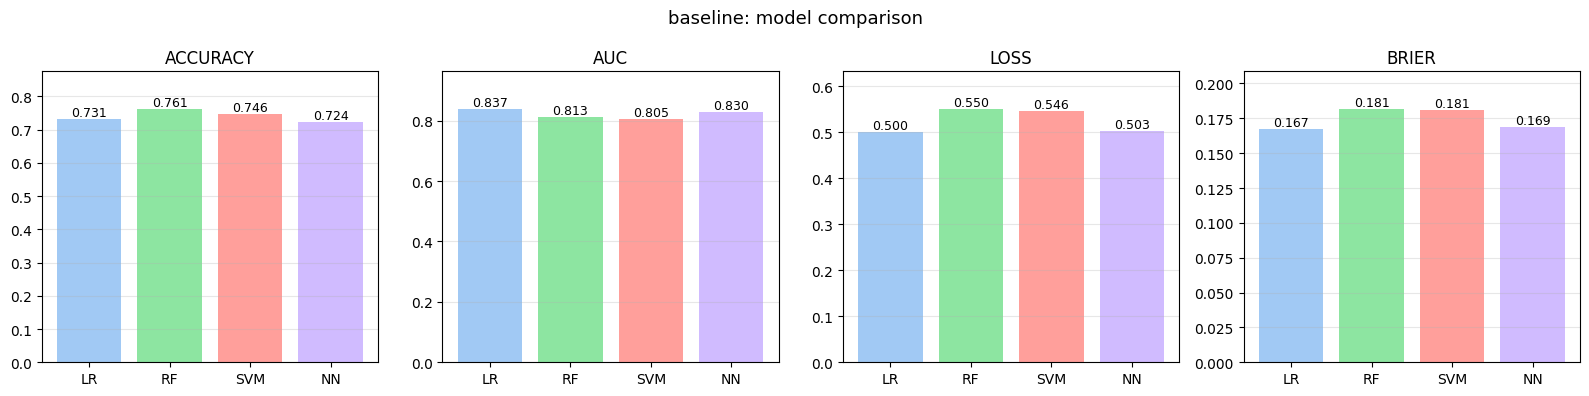

In [4]:
plot_experiment_metrics('baseline')

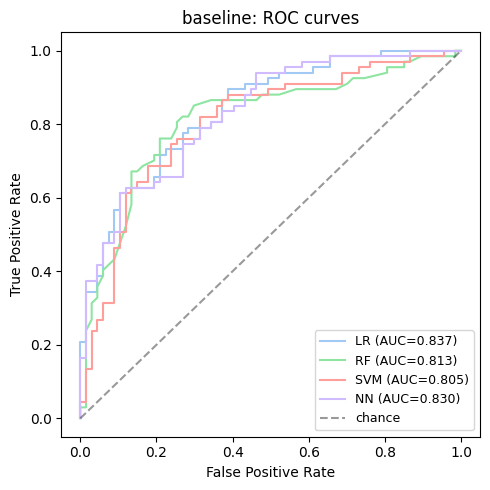

In [5]:
plot_roc('baseline')

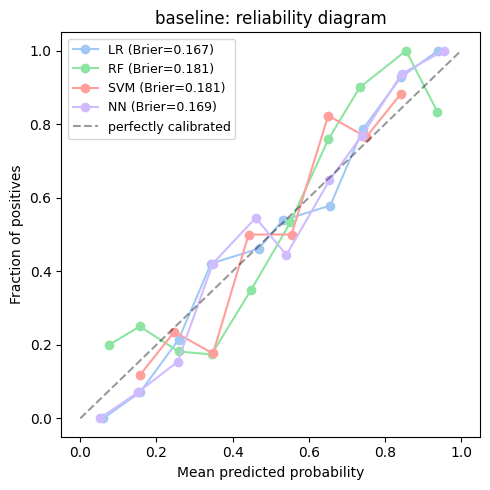

In [6]:
plot_reliability_diagram('baseline')

Here we see the general heuristic trends that rf is the best suited model for accuracy, but the lr's AUC is the highest likely because of generally linear decision boundaries

## Focal loss variant (nn only, baseline split)

In [7]:
focal_config = load_config('configs/focal.yaml')
nn_probs = get_nn_predictions(focal_config, X_test)
nn_metrics = evaluate(nn_probs, y_test)
print(nn_metrics)

# store alongside the baseline nn result so we can compare the two configs directly
results['baseline_focal_nn'] = {'NN (focal)': nn_metrics, 'NN (baseline)': results['baseline']['NN']}
probs['baseline_focal_nn'] = {'y_test': y_test, 'models': {'NN (focal)': nn_probs, 'NN (baseline)': probs['baseline']['models']['NN']}}

{'accuracy': 0.6940298507462687, 'auc': 0.8202272220984629, 'loss': 0.5461271047223949, 'brier': 0.1828475147485733}


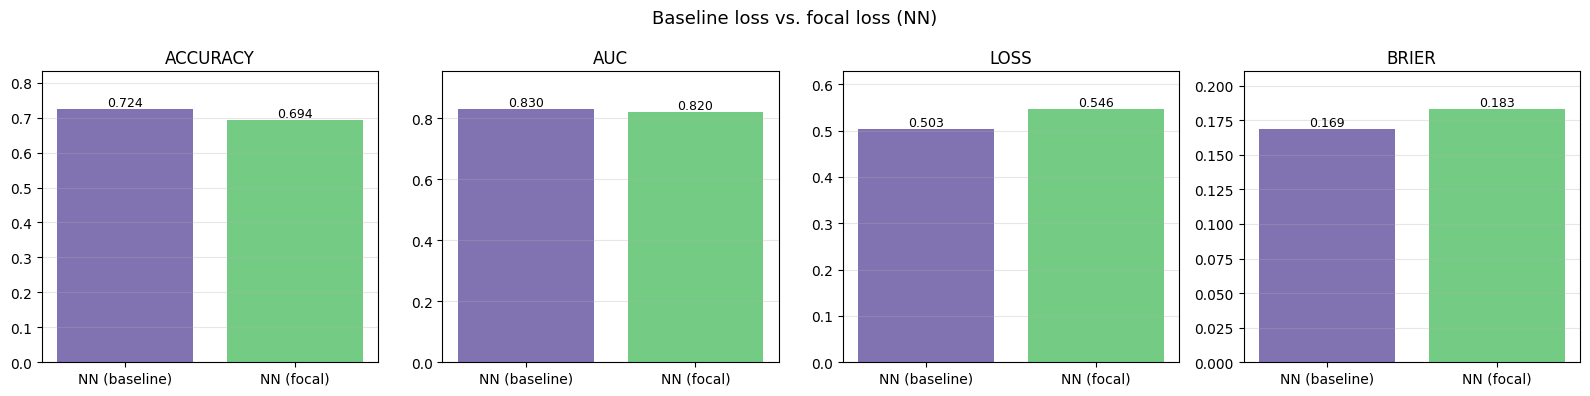

In [8]:
# focal loss vs. default loss, nn only
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metric_names = ['accuracy', 'auc', 'loss', 'brier']
configs = ['NN (baseline)', 'NN (focal)']
colors = ['#8172B2', "#74CC84"]
for ax, metric_name in zip(axes, metric_names):
    values = [results['baseline_focal_nn'][c][metric_name] for c in configs]
    bars = ax.bar(configs, values, color=colors)
    ax.set_title(metric_name.upper())
    ax.set_ylim(0, max(values) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Baseline loss vs. focal loss (NN)', fontsize=13)
plt.tight_layout()
plt.show()

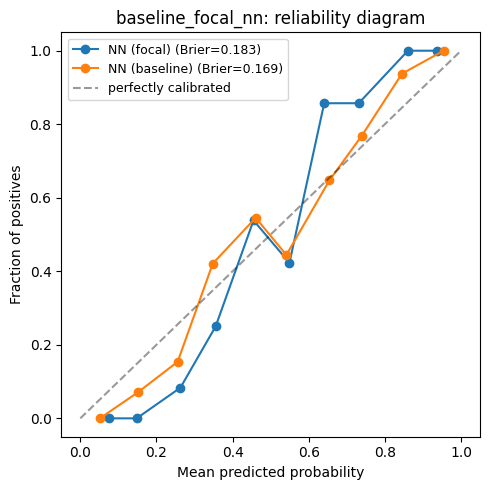

In [9]:
plot_reliability_diagram('baseline_focal_nn')

We observe that introducing a focusing parameter as an attempt to encourage learning of difficult matchups like upsets is not effective on our feature set or data size. The baseline BCE nn performs better on all three metrics

## Seed-based heuristic baseline

In [10]:
seed_preds = (X_test[:, -1] < 0).astype(int)
accuracy = float(np.mean(seed_preds == y_test))
print(accuracy)

results['seed_heuristic'] = {'Seed heuristic': {'accuracy': accuracy, 'auc': np.nan, 'loss': np.nan, 'brier': np.nan}}

0.7835820895522388


## Colley ratings feature set
Feature engineering screening tests suggest that colley is not a substantially informative feature given our dataset, but we still experiment with it since it is computationally cheap

In [11]:
colley_config = load_config('configs/colley.yaml')
X_train = np.load('data/splits/colley/X_train.npy')
y_train = np.load('data/splits/colley/y_train.npy')
X_test = np.load('data/splits/colley/X_test.npy')
y_test = np.load('data/splits/colley/y_test.npy')

colley_metrics = run_experiment('colley', X_train, y_train, X_test, y_test, colley_config)

LR: {'accuracy': 0.7611940298507462, 'auc': 0.8596569391846737, 'loss': 0.47148476585680954, 'brier': 0.1564350776294958}
RF: {'accuracy': 0.7686567164179104, 'auc': 0.8372688794831811, 'loss': 0.5208692777229568, 'brier': 0.1708149253731343}
SVM: {'accuracy': 0.746268656716418, 'auc': 0.813989752728893, 'loss': 0.5323653064205079, 'brier': 0.17534939665622484}
NN: {'accuracy': 0.7611940298507462, 'auc': 0.848741367787926, 'loss': 0.4800482599508624, 'brier': 0.16015106439590454}


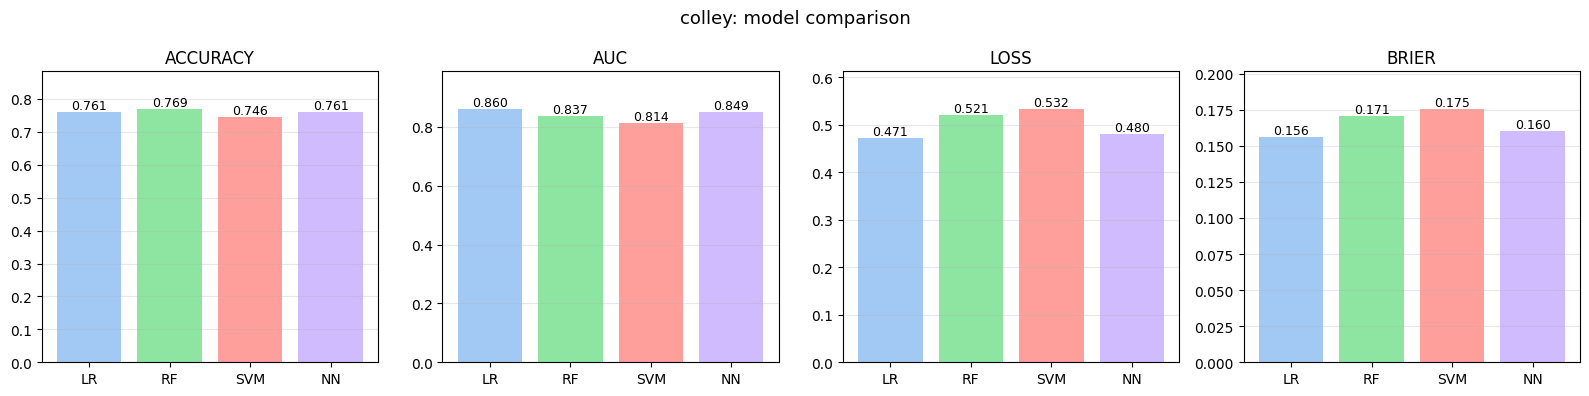

In [12]:
plot_experiment_metrics('colley')

The general trends hold here, though interestingly the SVM accuracy dropped more than other models. 

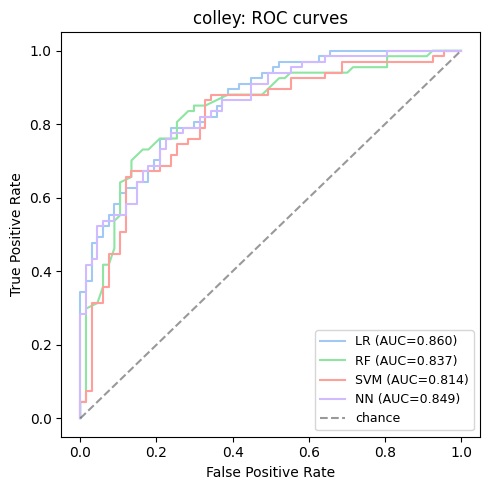

In [13]:
plot_roc('colley')

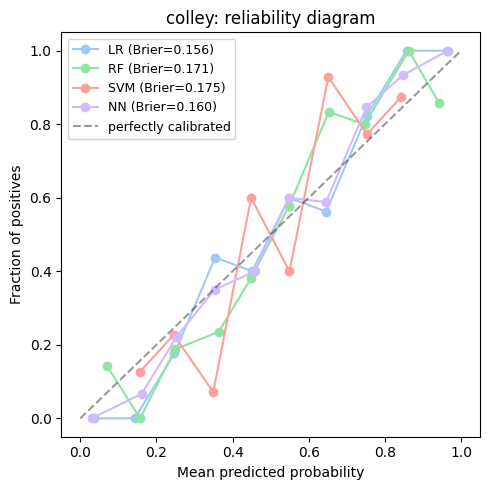

In [14]:
plot_reliability_diagram('colley')

## Colley + season feature set
We also experiment with adding the raw integer season as a feature, under the assumption that the models may find some complex relationship between stats and season that our experiments did not uncover, again computationally cheap

In [15]:
season_config = load_config('configs/season.yaml')
X_train = np.load('data/splits/colley-season/X_train.npy')
y_train = np.load('data/splits/colley-season/y_train.npy')
X_test = np.load('data/splits/colley-season/X_test.npy')
y_test = np.load('data/splits/colley-season/y_test.npy')

colley_season_metrics = run_experiment('colley-season', X_train, y_train, X_test, y_test, season_config)

LR: {'accuracy': 0.7611940298507462, 'auc': 0.8596569391846737, 'loss': 0.47148476585677446, 'brier': 0.1564350776294791}
RF: {'accuracy': 0.7835820895522388, 'auc': 0.8331476943640009, 'loss': 0.5360101263166573, 'brier': 0.17492835820895525}
SVM: {'accuracy': 0.7313432835820896, 'auc': 0.7885943417242147, 'loss': 0.5642252261712686, 'brier': 0.18885461721119415}
NN: {'accuracy': 0.7611940298507462, 'auc': 0.8449543328135443, 'loss': 0.5059127819990404, 'brier': 0.16815884411334991}


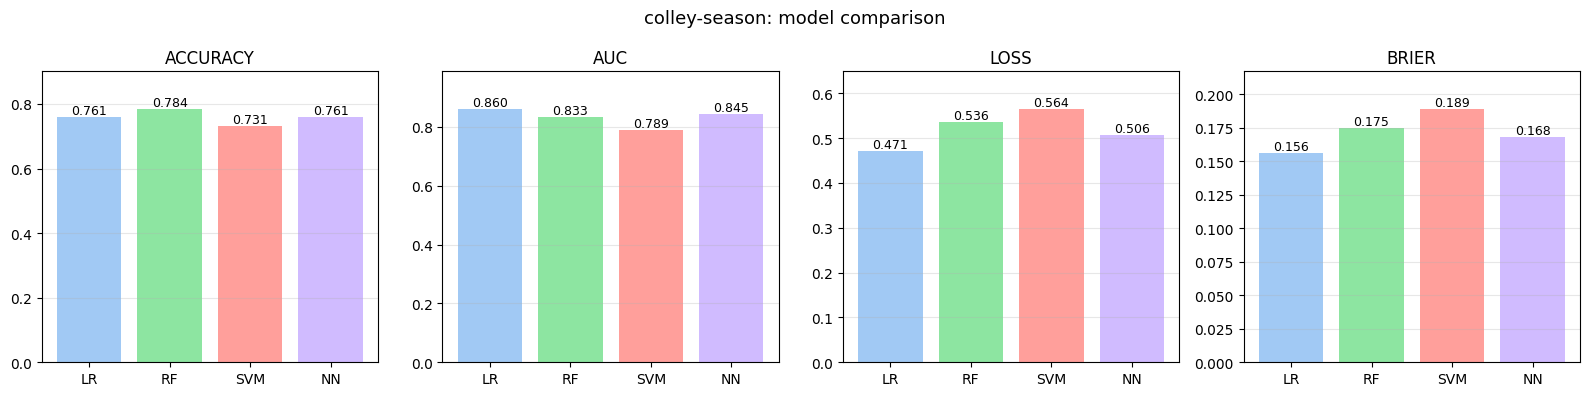

In [16]:
plot_experiment_metrics('colley-season')

Again the general shapes of these bar charts mirror the previous two experiments

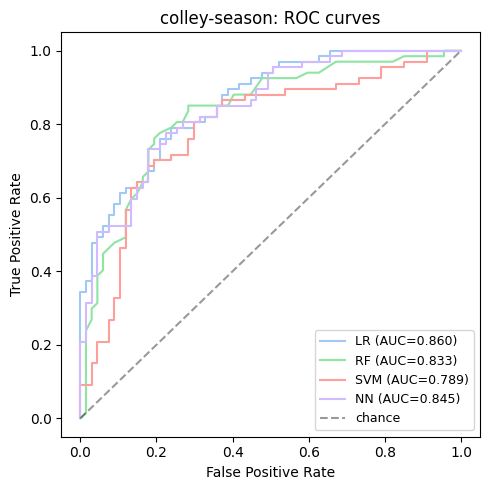

In [17]:
plot_roc('colley-season')

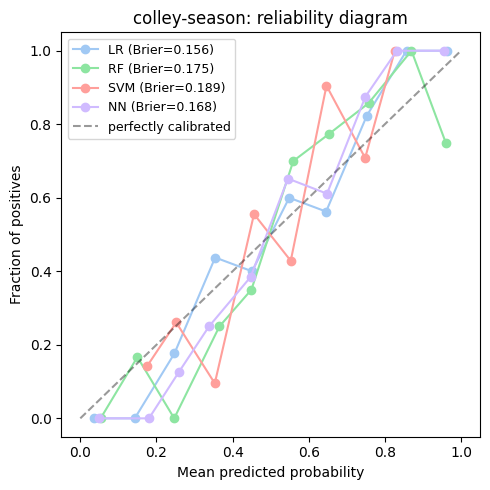

In [18]:
plot_reliability_diagram('colley-season')

## Upset feature set
This feature set and outcome prediction is completely different from the previous experiments. Here we intentionally format feature rows as comparing higher vs lower seeds, and using the same feature set as the baseline set the labels to indicate 'did an upset occur'. The result is that these models are predicting a fundamentally different probability and thus have their own set of results.

In [19]:
upset_config = load_config('configs/upset.yaml')
X_train = np.load('data/splits/upset/X_train.npy')
y_train = np.load('data/splits/upset/y_train.npy')
X_test = np.load('data/splits/upset/X_test.npy')
y_test = np.load('data/splits/upset/y_test.npy')

upset_metrics = run_experiment('upset', X_train, y_train, X_test, y_test, upset_config)

LR: {'accuracy': 0.7833333333333333, 'auc': 0.6846011131725418, 'loss': 0.46768292637476383, 'brier': 0.15266710429661828}
RF: {'accuracy': 0.7833333333333333, 'auc': 0.6326530612244898, 'loss': 0.5070409522177174, 'brier': 0.16527833333333336}
SVM: {'accuracy': 0.8, 'auc': 0.5547309833024119, 'loss': 0.5089358325211103, 'brier': 0.1631724042675397}
NN: {'accuracy': 0.8, 'auc': 0.6827458256029685, 'loss': 0.4817340037472426, 'brier': 0.15758341550827026}


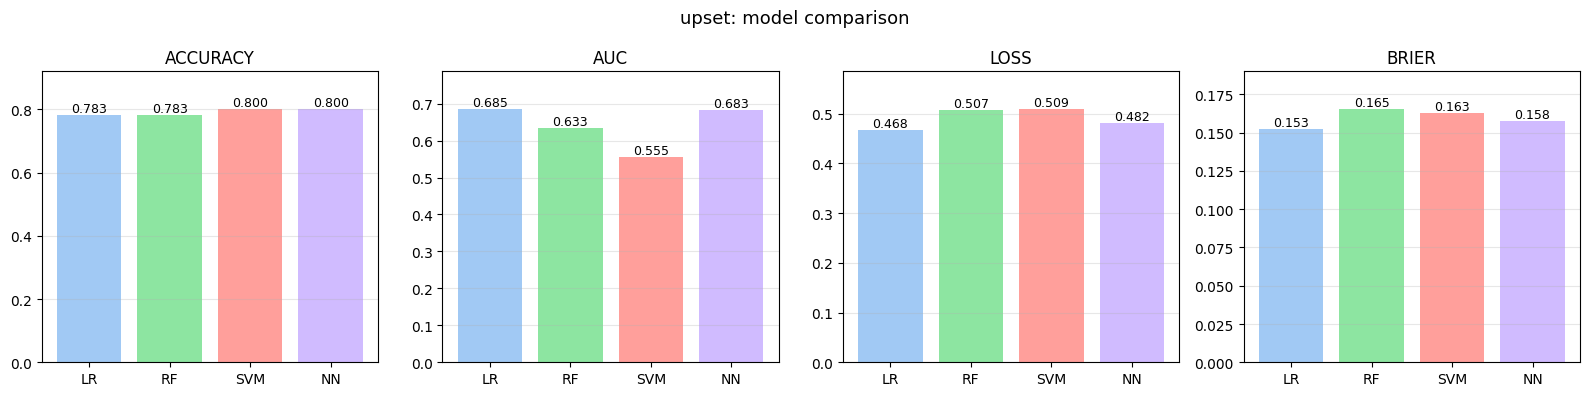

In [20]:
plot_experiment_metrics('upset')

The neural network performs marginally better here in this experiment, suggesting perhaps there are more complex non-linear relationships involved in selecting upsets, especially since the seed can no longer be used as a short cut in the same way

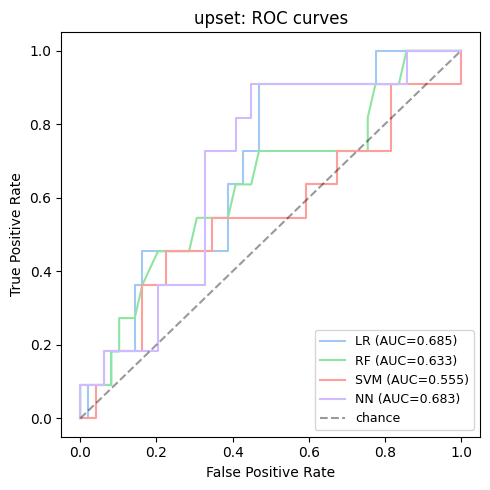

In [21]:
plot_roc('upset')

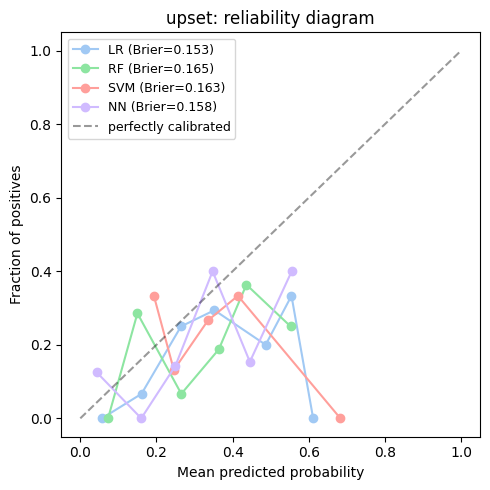

In [22]:
plot_reliability_diagram('upset')

## Comparison across all experiments

The individual per-experiment charts above are useful while iterating on one
feature set. The cells below pull every experiment's metrics into a single table, then visualize it as a
heatmap and as a grouped bar chart so the feature-set splits (baseline,
colley, colley-season, upset) can be compared and visualized. It is important to remember that the upset experiment is predicting upset probabilities, a fundamentally different outcome and thus cannot be directly compared to the other experiments.

In [23]:
# one row per (experiment, model), columns = metrics
main_experiments = ['baseline', 'colley', 'colley-season', 'upset']

rows = []
for label in main_experiments:
    for model_name, m in results[label].items():
        rows.append({'experiment': label, 'model': model_name, **m})
summary_df = pd.DataFrame(rows)
summary_df

,experiment,model,accuracy,auc,loss,brier
0,baseline,LR,0.731343,0.837380,0.500071,0.167376
1,baseline,RF,0.761194,0.813433,0.550414,0.181468
2,baseline,SVM,0.746269,0.804634,0.545917,0.181229
3,baseline,NN,0.723881,0.830029,0.503179,0.168719
4,colley,LR,0.761194,0.859657,0.471485,0.156435
5,colley,RF,0.768657,0.837269,0.520869,0.170815
6,colley,SVM,0.746269,0.813990,0.532365,0.175349
7,colley,NN,0.761194,0.848741,0.480048,0.160151
8,colley-season,LR,0.761194,0.859657,0.471485,0.156435
9,colley-season,RF,0.783582,0.833148,0.536010,0.174928


### Heatmap of accuracy across experiment x model

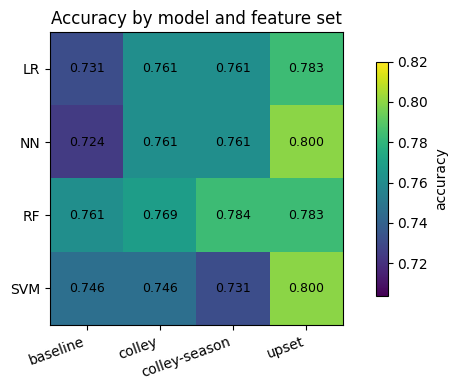

In [24]:
pivot_acc = summary_df.pivot(index='model', columns='experiment', values='accuracy')[main_experiments]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot_acc.values, cmap='viridis', vmin=pivot_acc.values.min() - 0.02, vmax=pivot_acc.values.max() + 0.02)
ax.set_xticks(range(len(pivot_acc.columns)))
ax.set_xticklabels(pivot_acc.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot_acc.index)))
ax.set_yticklabels(pivot_acc.index)
for i in range(pivot_acc.shape[0]):
    for j in range(pivot_acc.shape[1]):
        ax.text(j, i, f'{pivot_acc.values[i, j]:.3f}', ha='center', va='center', fontsize=9)
ax.set_title('Accuracy by model and feature set')
fig.colorbar(im, ax=ax, shrink=0.8, label='accuracy')
plt.tight_layout()
plt.show()

We see visually here that the random forest is the best performer by accuracy across all win based feature sets, following our expectations.  The upset feature set is again fundamentally different, though the strong performance of the nn is still the most interesting

### Grouped bar chart: accuracy per model, grouped by experiment

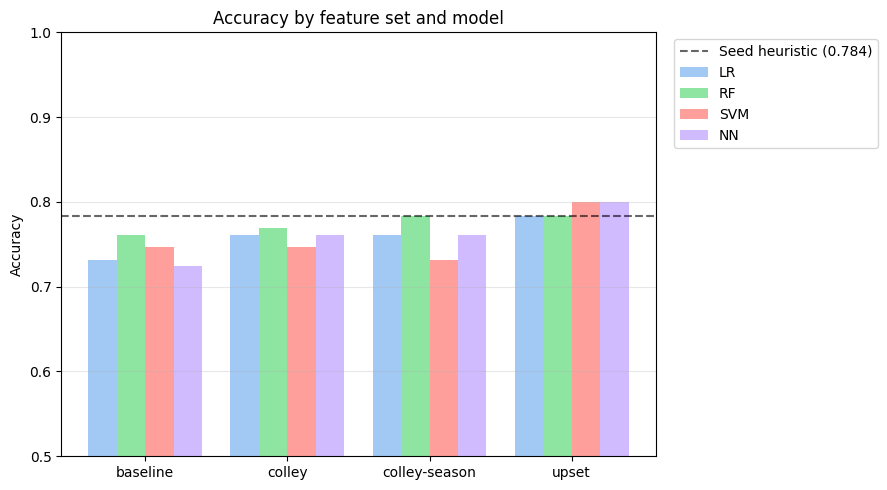

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
model_names = ['LR', 'RF', 'SVM', 'NN']
x = np.arange(len(main_experiments))
width = 0.2

for i, model_name in enumerate(model_names):
    values = [results[exp][model_name]['accuracy'] for exp in main_experiments]
    ax.bar(x + (i - 1.5) * width, values, width, label=model_name, color=MODEL_COLORS[model_name])

seed_acc = results['seed_heuristic']['Seed heuristic']['accuracy']
ax.axhline(seed_acc, color='black', linestyle='--', alpha=0.6, label=f'Seed heuristic ({seed_acc:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(main_experiments)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.0)
ax.set_title('Accuracy by feature set and model')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

No model trained to predict outcomes outperforms the simple chalk predictions on accuracy. It is interesting to observe that the colley-season feature set is the highest performer despite colley providing marginal information.

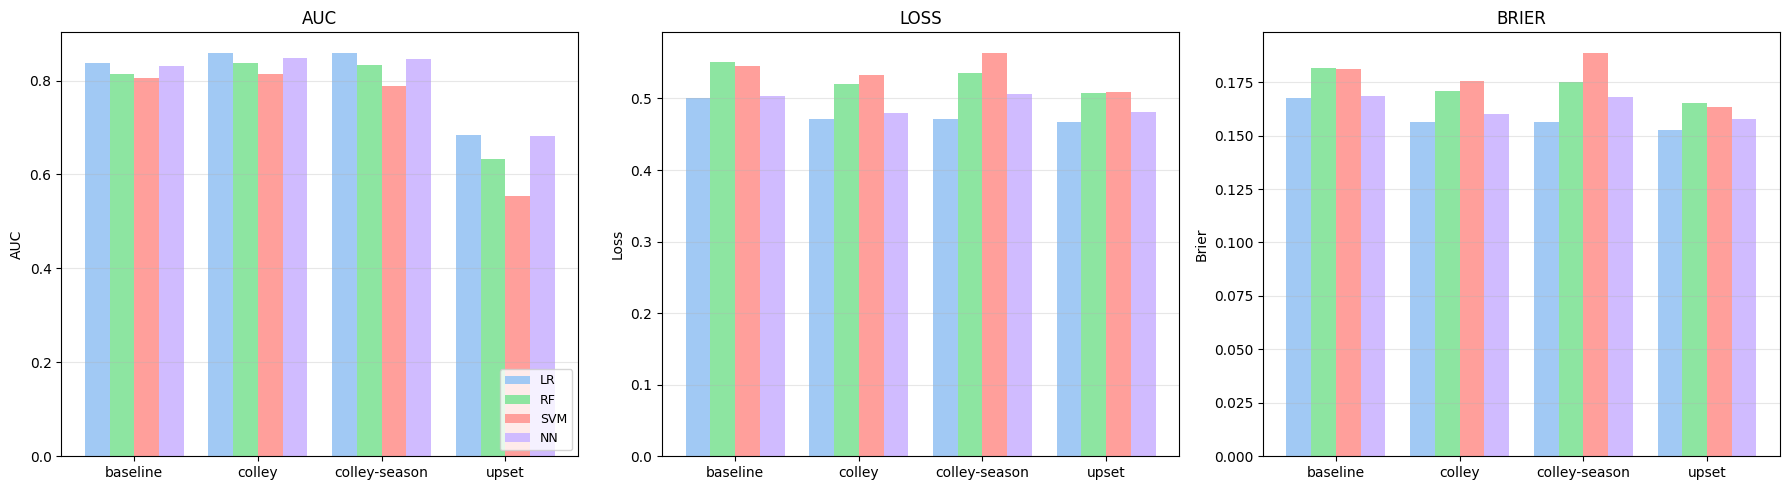

In [26]:
# Same comparison, but for AUC, loss, and brier score, so all three metrics are visible side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_labels = {'auc': 'AUC', 'loss': 'Loss', 'brier': 'Brier'}
for ax, metric_name in zip(axes, ['auc', 'loss', 'brier']):
    for i, model_name in enumerate(model_names):
        values = [results[exp][model_name][metric_name] for exp in main_experiments]
        ax.bar(x + (i - 1.5) * width, values, width, label=model_name, color=MODEL_COLORS[model_name])
    ax.set_xticks(x)
    ax.set_xticklabels(main_experiments)
    ax.set_title(metric_name.upper())
    ax.set_ylabel(metric_labels[metric_name])
    ax.grid(axis='y', alpha=0.3)
axes[0].legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

The AUC and log loss bars all follow similar patters across all experiments. Ignoring the upset feature set, all other feature sets are very closely clustered in both metrics. 

## Statistical significance

The bar charts above are useful for seeing rough trends, but a lot of the
gaps between models are in the hundredths of a point, which is well within
the range you'd expect from noise on a single tournament's worth of test
games. To actually claim one model beats another, we need a test that asks
"do these two models disagree with each other more often in one direction
than the other?" rather than just comparing two point estimates.

We use McNemar's for two models
evaluated on the same test games, it only looks at the games where the two
models disagree and tests whether that
disagreement is roughly a 50/50 split (which would be expected if the models
were equally good) or lopsided in one model's favor. It ignores games where
both models agree, since those carry no information about which model is
better. Note that this only tests differences in accuracy at the 0.5
threshold, not AUC or log loss. We expect all models to require the exact test rather
than the chi-squared version since the effective sample sizes should be consistently small.

Since we're testing every pair of models on each dataset (6 pairwise
comparisons for 4 models), we apply a Holm-Bonferroni correction across
each experiment's comparisons to control the false-positive rate that comes
from running multiple tests at once.

In [27]:
def mcnemar_test(y_true, probs_a, probs_b, threshold=0.5, correction=True, exact_below=25):
    '''McNemar's test comparing two models' predictions on the same test set.

    Only the discordant pairs matter: b = model A correct & model B wrong,
    c = model A wrong & model B correct. Uses the exact binomial test when
    there are few discordant games (recommended when b + c < ~25, which is
    typical for a single tournament's test set) and falls back to the
    chi-square approximation (with continuity correction) otherwise.
    Returns a dict with the contingency counts, test statistic, and p-value.
    '''
    pred_a = (np.asarray(probs_a) >= threshold).astype(int)
    pred_b = (np.asarray(probs_b) >= threshold).astype(int)
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    b = int(np.sum(correct_a & ~correct_b))   # only A correct
    c = int(np.sum(~correct_a & correct_b))   # only B correct
    n_discordant = b + c

    if n_discordant == 0:
        return {'b': b, 'c': c, 'n_discordant': 0, 'statistic': np.nan,
                'p_value': 1.0, 'method': 'exact (no disagreement)'}

    if n_discordant < exact_below:
        stat = min(b, c)
        p_value = binomtest(stat, n_discordant, p=0.5, alternative='two-sided').pvalue
        method = 'exact'
    else:
        stat = (abs(b - c) - 1) ** 2 / n_discordant if correction else (b - c) ** 2 / n_discordant
        p_value = 1 - chi2.cdf(stat, df=1)
        method = 'chi2'

    return {'b': b, 'c': c, 'n_discordant': n_discordant, 'statistic': stat,
            'p_value': p_value, 'method': method}


def holm_bonferroni(p_values):
    '''Holm-Bonferroni step-down correction. Returns adjusted p-values in the
    same order as the input (safe to use even when p-values repeat).'''
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(n)
    running_max = 0.0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (n - rank) * p_values[idx])
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


def compare_models_mcnemar(label, alpha=0.05, threshold=0.5):
    '''Run McNemar's test between every pair of models trained on the given
    experiment, using the predicted probabilities already stashed in `probs`
    by run_experiment(). Applies a Holm-Bonferroni correction across the
    pairwise comparisons for this one experiment.'''
    entry = probs[label]
    y_true = entry['y_test']
    model_names = list(entry['models'].keys())

    rows = []
    for model_a, model_b in combinations(model_names, 2):
        res = mcnemar_test(y_true, entry['models'][model_a], entry['models'][model_b], threshold=threshold)
        rows.append({'experiment': label, 'model_a': model_a, 'model_b': model_b, **res})

    df = pd.DataFrame(rows)
    df['p_value_holm'] = holm_bonferroni(df['p_value'].values)
    df['significant'] = df['p_value_holm'] < alpha
    return df


def compare_all_experiments_mcnemar(labels=None, alpha=0.05, threshold=0.5):
    '''Run compare_models_mcnemar for every experiment with stored predictions
    (or just the given labels) and concatenate into one table.'''
    labels = labels if labels is not None else list(probs.keys())
    return pd.concat(
        [compare_models_mcnemar(label, alpha=alpha, threshold=threshold) for label in labels],
        ignore_index=True,
    )

We compare the p value and the holm-bonferroni p value across all model comparisons

In [28]:
mcnemar_results = compare_all_experiments_mcnemar(main_experiments)
mcnemar_results

,experiment,model_a,model_b,b,c,n_discordant,statistic,p_value,method,p_value_holm,significant
0,baseline,LR,RF,5,9,14,5,0.423950,exact,1.000000,False
1,baseline,LR,SVM,6,8,14,6,0.790527,exact,1.000000,False
2,baseline,LR,NN,3,2,5,2,1.000000,exact,1.000000,False
3,baseline,RF,SVM,8,6,14,6,0.790527,exact,1.000000,False
4,baseline,RF,NN,11,6,17,6,0.332306,exact,1.000000,False
5,baseline,SVM,NN,9,6,15,6,0.607239,exact,1.000000,False
6,colley,LR,RF,9,8,17,8,1.000000,exact,1.000000,False
7,colley,LR,SVM,10,8,18,8,0.814529,exact,1.000000,False
8,colley,LR,NN,3,3,6,3,1.000000,exact,1.000000,False
9,colley,RF,SVM,9,8,17,8,1.000000,exact,1.000000,False


No model has a statistically significant advantage over any other model in any feature set. The most significant difference is in the colley season feature set where the rf outperforms the svm at a significance level of $\alpha = .3$, hardly a meaningful result or difference. While raw accuracy scores varied slightly across the evaluated models and feature sets, pairwise comparisons using McNemar’s test revealed no statistically significant differences in predictive performance. As a result, the reasonable conclusion is to preference the simple logistic regression or even just seed based heuristics when making these predictions. 